# Credit Card Fraud Detection: A Cost-Based Approach

**By: PIYA JOLLY**

Fraud detection is a deceptively hard problem. Fraud is extremely rare (here, under 0.2% of transactions), which means a model can be 99.8% accurate while catching almost no fraud at all. Accuracy is the wrong lens.

This notebook works through the problem the way a risk team would: not "how accurate is the model?" but **"what does each type of mistake cost the business, and where should we set the decision boundary?"**

**Approach:**
1. Explore the data and confront the class imbalance
2. Build a baseline model and expose why accuracy misleads
3. Handle the imbalance, and watch it overcorrect
4. Train a stronger model (XGBoost) that balances the tradeoff
5. Assign real dollar costs to errors and choose the model on cost, not accuracy
6. Tune the decision threshold to the cost-optimal point

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

# Quick look at the shape and first few rows
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 284,807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. How rare is fraud?

Before any modelling, we need to understand the imbalance, because it shapes every decision that follows.

Legitimate (Class 0): 284,315
Fraud (Class 1):      492

Fraud is 0.173% of all transactions
That's roughly 1 fraud in every 579 transactions


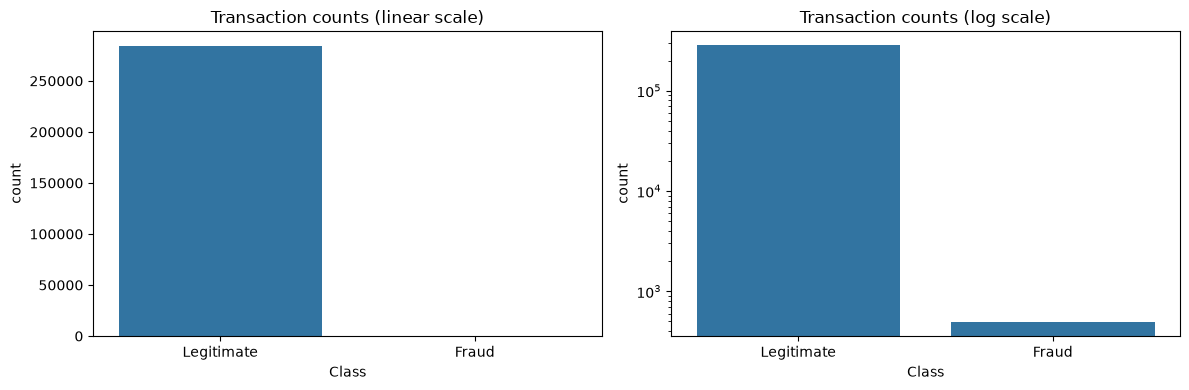

In [45]:
# How many fraud vs legitimate transactions?
class_counts = df["Class"].value_counts()
fraud_pct = df["Class"].mean() * 100

print(f"Legitimate (Class 0): {class_counts[0]:,}")
print(f"Fraud (Class 1):      {class_counts[1]:,}")
print(f"\nFraud is {fraud_pct:.3f}% of all transactions")
print(f"That's roughly 1 fraud in every {round(1/df['Class'].mean()):,} transactions")

# Visualise the imbalance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Class", data=df, ax=ax[0])
ax[0].set_title("Transaction counts (linear scale)")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x="Class", data=df, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Transaction counts (log scale)")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

## 2. Do fraudulent transactions look different?

A quick check for missing data, then a look at whether fraud has a different spending fingerprint to legitimate activity.

Missing values per column: 0

Transaction Amount summary:
             mean    50%       max
Class                             
0       88.291022  22.00  25691.16
1      122.211321   9.25   2125.87


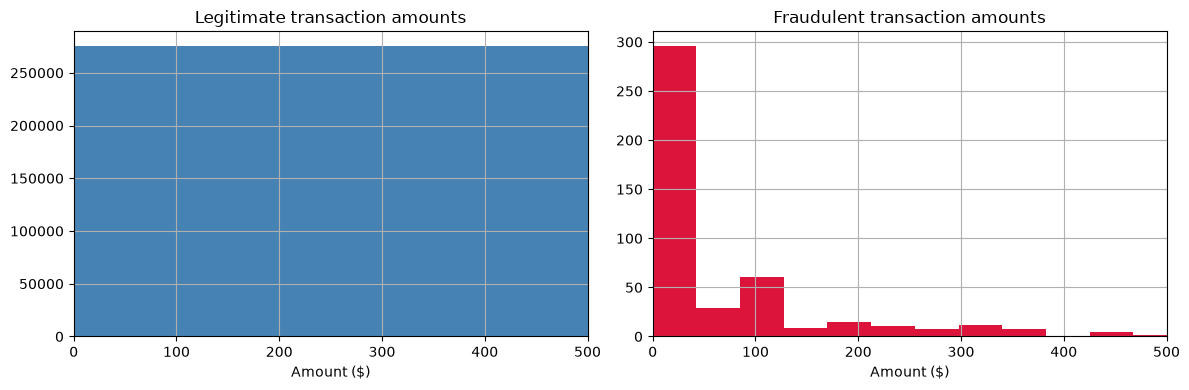

In [46]:
# 1. Any missing values? (models hate missing data)
print("Missing values per column:", df.isnull().sum().sum())

# 2. Does transaction Amount differ between fraud and legit?
print("\nTransaction Amount summary:")
print(df.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]])

# 3. Visualise Amount distribution for each class
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df[df["Class"] == 0]["Amount"].hist(bins=50, ax=ax[0], color="steelblue")
ax[0].set_title("Legitimate transaction amounts")
ax[0].set_xlabel("Amount ($)")
ax[0].set_xlim(0, 500)

df[df["Class"] == 1]["Amount"].hist(bins=50, ax=ax[1], color="crimson")
ax[1].set_title("Fraudulent transaction amounts")
ax[1].set_xlabel("Amount ($)")
ax[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

## 3. A baseline model, and the accuracy trap

We start simple with logistic regression. Watch the accuracy score: it looks excellent. Then we look at the confusion matrix, which tells the real story that accuracy hides.

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# The V1-V28 columns are already scaled (they came from PCA).
# But Time and Amount are on very different scales, so we scale them too.
df_prepped = df.copy()
scaler = StandardScaler()
df_prepped["Amount_scaled"] = scaler.fit_transform(df_prepped[["Amount"]])
df_prepped["Time_scaled"] = scaler.fit_transform(df_prepped[["Time"]])

# Drop the original unscaled versions
df_prepped = df_prepped.drop(["Amount", "Time"], axis=1)

# Separate features (X) from the target (y)
X = df_prepped.drop("Class", axis=1)
y = df_prepped["Class"]

# Split into train and test sets.
# stratify=y keeps the same fraud ratio in both sets (critical for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Test set:     {X_test.shape[0]:,} transactions")
print(f"\nFraud in training set: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test set:     {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Training set: 227,845 transactions
Test set:     56,962 transactions

Fraud in training set: 394 (0.173%)
Fraud in test set:     98 (0.172%)


## 4. Correcting for imbalance

The baseline misses too much fraud because it rarely saw fraud during training. We tell the model to treat each fraud case as far more important. This catches much more fraud, but watch what happens to false alarms: the model overcorrects and flags a large number of legitimate customers.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a simple logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the held-out test set
y_pred = model.predict(X_test)

# The "impressive" number
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

# The confusion matrix shows what accuracy hides
cm = confusion_matrix(y_test, y_pred)
print("-"*60)
print("Confusion Matrix:")
print(f"                     Predicted Legit   Predicted Fraud")
print(f"Actually Legit          {cm[0][0]:>6,}            {cm[0][1]:>4}")
print(f"Actually Fraud          {cm[1][0]:>6}            {cm[1][1]:>4}")

print("-"*60)

print("\nWhat this means in business terms:")
print(f"  True frauds caught:        {cm[1][1]} out of {cm[1][0]+cm[1][1]}")
print(f"  Frauds MISSED:             {cm[1][0]}  (these cost the bank money)")
print(f"  Legit flagged as fraud:    {cm[0][1]}  (these annoy customers)")

print("-"*60)

print("\nFull report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

Accuracy: 99.92%
------------------------------------------------------------
Confusion Matrix:
                     Predicted Legit   Predicted Fraud
Actually Legit          56,851              13
Actually Fraud              35              63
------------------------------------------------------------

What this means in business terms:
  True frauds caught:        63 out of 98
  Frauds MISSED:             35  (these cost the bank money)
  Legit flagged as fraud:    13  (these annoy customers)
------------------------------------------------------------

Full report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 4. Correcting for imbalance

The baseline misses too much fraud because it rarely saw fraud during training. We tell the model to treat each fraud case as far more important. This catches much more fraud, but watch what happens to false alarms: the model overcorrects and flags a large number of legitimate customers.

In [49]:
# Same model, but now it treats fraud as more important via class_weight
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced")
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)

cm_w = confusion_matrix(y_test, y_pred_weighted)
print("With class_weight='balanced':\n")
print(f"                     Predicted Legit   Predicted Fraud")
print(f"Actually Legit          {cm_w[0][0]:>6,}          {cm_w[0][1]:>4}")
print(f"Actually Fraud          {cm_w[1][0]:>6}          {cm_w[1][1]:>4}")

print("-"*60)

print(f"\n  Frauds caught:   {cm_w[1][1]} out of {cm_w[1][0]+cm_w[1][1]}  (was 63)")
print(f"  Frauds missed:   {cm_w[1][0]}  (was 35)")
print(f"  Legit flagged:   {cm_w[0][1]}  (was 13)")

print("-"*60)

print("\n" + classification_report(y_test, y_pred_weighted, target_names=["Legit", "Fraud"]))

With class_weight='balanced':

                     Predicted Legit   Predicted Fraud
Actually Legit          55,475          1389
Actually Fraud               8            90
------------------------------------------------------------

  Frauds caught:   90 out of 98  (was 63)
  Frauds missed:   8  (was 35)
  Legit flagged:   1389  (was 13)
------------------------------------------------------------

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



## 5. The core tradeoff: precision vs recall

There is no single "best" setting. Catching more fraud (higher recall) means more false alarms (lower precision), and vice versa. This curve shows the full tradeoff across every possible decision threshold. Choosing where to sit on this curve is a business decision, not a purely technical one.

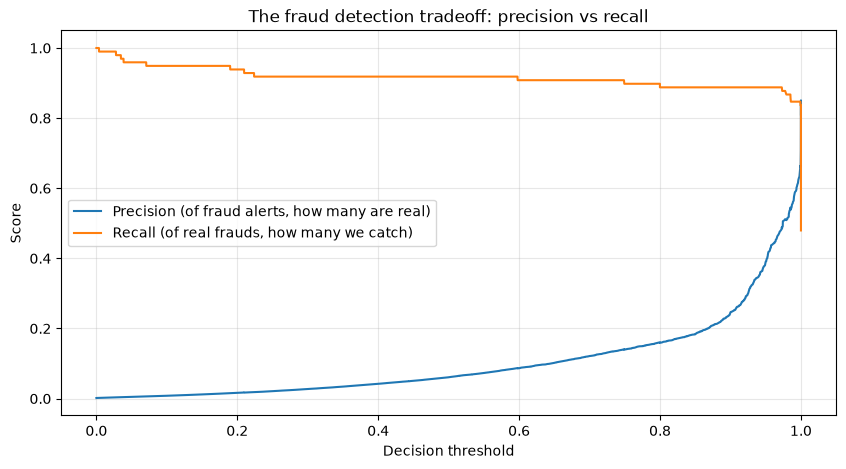

In [50]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

# Get the model's predicted PROBABILITIES (not just 0/1 decisions)
y_scores = model_weighted.predict_proba(X_test)[:, 1]

# Precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Plot how they trade off as the threshold changes
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision (of fraud alerts, how many are real)")
plt.plot(thresholds, recalls[:-1], label="Recall (of real frauds, how many we catch)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("The fraud detection tradeoff: precision vs recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. A stronger model: XGBoost

Logistic regression draws linear boundaries. Fraud patterns are often non-linear and involve interactions between features, so a gradient-boosted tree model should capture them better. The goal is a model that catches most fraud without drowning the business in false alarms.

In [51]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's version of class_weight='balanced'.
# We set it to the ratio of legit-to-fraud so fraud gets weighted up.
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Weighting fraud {ratio:.0f}x to counter the imbalance\n")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

cm_x = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost results:\n")
print(f"                     Predicted Legit   Predicted Fraud")
print(f"Actually Legit          {cm_x[0][0]:>6,}          {cm_x[0][1]:>4}")
print(f"Actually Fraud          {cm_x[1][0]:>6}          {cm_x[1][1]:>4}")

print("-"*60)

print(f"\n  Frauds caught:   {cm_x[1][1]} out of {cm_x[1][0]+cm_x[1][1]}")
print(f"  Frauds missed:   {cm_x[1][0]}")
print(f"  Legit flagged:   {cm_x[0][1]}")

print("-"*60)

print("\n" + classification_report(y_test, y_pred_xgb, target_names=["Legit", "Fraud"]))

Weighting fraud 577x to counter the imbalance

XGBoost results:

                     Predicted Legit   Predicted Fraud
Actually Legit          56,817            47
Actually Fraud              14            84
------------------------------------------------------------

  Frauds caught:   84 out of 98
  Frauds missed:   14
  Legit flagged:   47
------------------------------------------------------------

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.64      0.86      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962



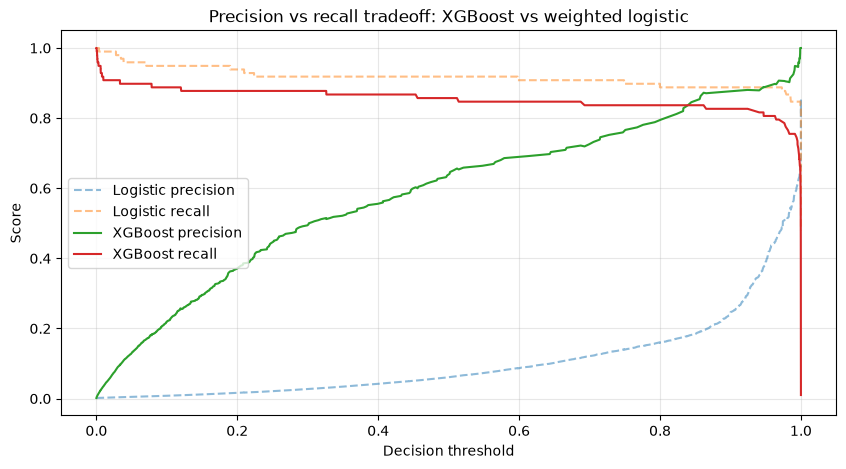

In [52]:
# Precision-recall tradeoff for XGBoost (compare against the weighted logistic curve)
y_scores_xgb = xgb.predict_proba(X_test)[:, 1]
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, y_scores_xgb)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], "--", alpha=0.5, label="Logistic precision")
plt.plot(thresholds, recalls[:-1], "--", alpha=0.5, label="Logistic recall")
plt.plot(thr_xgb, prec_xgb[:-1], label="XGBoost precision")
plt.plot(thr_xgb, rec_xgb[:-1], label="XGBoost recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision vs recall tradeoff: XGBoost vs weighted logistic")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Choosing a model on cost, not accuracy

This is the heart of the analysis. We assign a dollar cost to each type of error: a missed fraud costs far more than a false alarm. Totalling these costs gives an objective, business-aligned way to compare models, and it can overturn the intuition that the highest-recall model is best.

*Note: the cost figures used here are illustrative. The "best" model genuinely depends on them, which is exactly why they should be set with the business rather than assumed.*

In [53]:
# Assign business costs to each type of error (illustrative figures)
COST_MISSED_FRAUD = 150     # avg loss when a fraud slips through
COST_FALSE_ALARM = 5        # cost of reviewing / friction for a wrongly-flagged legit txn

def total_cost(cm):
    missed = cm[1][0]       # false negatives
    false_alarms = cm[0][1] # false positives
    return missed * COST_MISSED_FRAUD + false_alarms * COST_FALSE_ALARM

results = {
    "Logistic (plain)":     cm,
    "Logistic (weighted)":  cm_w,
    "XGBoost":              cm_x,
}

print(f"Assuming a missed fraud costs ${COST_MISSED_FRAUD} and a false alarm costs ${COST_FALSE_ALARM}:\n")
print(f"{'Model':<22}{'Missed':>8}{'FalseAlarm':>12}{'Total cost':>14}")
print("-" * 56)
for name, matrix in results.items():
    print(f"{name:<22}{matrix[1][0]:>8}{matrix[0][1]:>12}{'$' + format(total_cost(matrix), ','):>14}")

Assuming a missed fraud costs $150 and a false alarm costs $5:

Model                   Missed  FalseAlarm    Total cost
--------------------------------------------------------
Logistic (plain)            35          13        $5,315
Logistic (weighted)          8        1389        $8,145
XGBoost                     14          47        $2,335


## 8. Tuning the decision threshold

The model outputs a probability, and we choose a threshold to turn that into a decision. The default of 0.5 is arbitrary. Since we now have a cost function, we can sweep every threshold and pick the one that minimises total business cost, showing that the decision boundary itself is a lever to be tuned, not a fixed default.

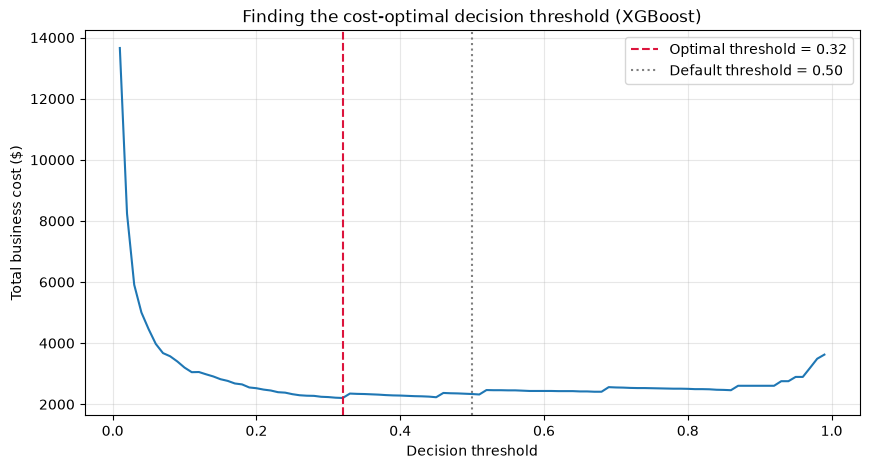

Default threshold (0.50) cost:   $2,335
Optimal threshold (0.32) cost:  $2,205

At the optimal threshold:
  Frauds caught: 86 / 98
  Frauds missed: 12
  Legit flagged: 81


In [54]:
# Sweep every threshold on XGBoost and compute the business cost at each
thresholds_sweep = np.linspace(0.01, 0.99, 99)
costs = []

for t in thresholds_sweep:
    preds = (y_scores_xgb >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds)
    missed = cm_t[1][0]
    false_alarms = cm_t[0][1]
    costs.append(missed * COST_MISSED_FRAUD + false_alarms * COST_FALSE_ALARM)

costs = np.array(costs)
best_idx = costs.argmin()
best_threshold = thresholds_sweep[best_idx]
best_cost = costs[best_idx]

# Plot cost vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds_sweep, costs)
plt.axvline(best_threshold, color="crimson", linestyle="--",
            label=f"Optimal threshold = {best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
plt.xlabel("Decision threshold")
plt.ylabel("Total business cost ($)")
plt.title("Finding the cost-optimal decision threshold (XGBoost)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Show the improvement
cm_best = confusion_matrix(y_test, (y_scores_xgb >= best_threshold).astype(int))
print(f"Default threshold (0.50) cost:   ${total_cost(cm_x):,}")
print(f"Optimal threshold ({best_threshold:.2f}) cost:  ${best_cost:,}")
print(f"\nAt the optimal threshold:")
print(f"  Frauds caught: {cm_best[1][1]} / 98")
print(f"  Frauds missed: {cm_best[1][0]}")
print(f"  Legit flagged: {cm_best[0][1]}")

In [55]:
import joblib
import os

# Create a folder to hold the saved model artifacts
os.makedirs("../app_artifacts", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(xgb, "../app_artifacts/xgb_model.pkl")

# Save the fitted scaler (so the app scales new inputs the same way)
joblib.dump(scaler, "../app_artifacts/scaler.pkl")

# Save the test set with predicted probabilities, for the app to demo on
import pandas as pd
demo = X_test.copy()
demo["Class"] = y_test.values
demo["fraud_prob"] = xgb.predict_proba(X_test)[:, 1]
demo.to_csv("../app_artifacts/demo_data.csv", index=False)

print("Saved: xgb_model.pkl, scaler.pkl, demo_data.csv")
print(f"Demo data: {len(demo):,} transactions with predictions")

Saved: xgb_model.pkl, scaler.pkl, demo_data.csv
Demo data: 56,962 transactions with predictions
